# ASMC Method Tutorial

In this file we exemplify the workflow to use the `polynomial_sampler.py` module on a toy-model potential.

1. First we obtain a set of 10_000 numerical minima to the potential $V(x) = (x^2 + y^2 -1)^2$, stored as a (10_000, 2)-array
2. Using SparsePolynomialSampler, the locus $x^2 + y^2 = 1$ is reconstructed

In [24]:
# Importing packages
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import sympy

from ASMC import SparsePolynomialSampler
from ASMC import utils

from typing import Callable, Optional

## Moduli Space Sampling -- Gradient Descent

In [4]:
def grad_norm_squared(
        V: Callable[[tf.Tensor], tf.Tensor],
        x: tf.Tensor,
        non_zero: Optional[list] = None,
        factor: float=1.0):
    """
    Compute the squared L2 norm of the gradient of V wrt x, 
    evaluated on x with only `non_zero` indices active.

    Parameters
    ----------
    V : callable
        Function mapping x to outputs (batch_size, 1).
    x : tf.Tensor
        Input tensor of shape (batch_size, n_vars).
    non_zero : list of int
        Indices of x to keep; others are zeroed. Takes all indices by default.
    factor : float, optional
        Scaling factor for the squared gradient norm.

    Returns
    -------
    tf.Tensor
        Scaled squared gradient norm of shape (batch_size,).
    """
    n_vars = x.shape[1]

    if non_zero is None or len(non_zero) == 0:
        non_zero = list(range(n_vars))

    mask = tf.constant([1.0 if i in non_zero else 0.0 for i in range(n_vars)], dtype=x.dtype)
    
    with tf.GradientTape() as tape:
        tape.watch(x)
        x_masked = x * mask  
        y = V(x_masked)

    gradients = tape.gradient(y, x)
    return factor * tf.reduce_sum(gradients**2, axis=1)

In [67]:
# Definition of Potential
def V_Higgs(x):
    x1, x2 = tf.split(x, 2, axis=1)
    return (x1**2 + x2**2 -1)**2

# Randomly initialize the points
n_points = 1000
x_2d = tf.Variable(4*np.random.rand(n_points, 2)-2, dtype=tf.float32)

history_2d = []
history_loss_2d = []

# Definition of optimizer
alpha = 1e-3
optimizer = tf.keras.optimizers.Adam(learning_rate=alpha)

# Learning loop 
for step in range(2000):  
    with tf.GradientTape() as tape:       
        grad_norm_squared_this_step = grad_norm_squared(V_Higgs, x_2d)
        # minimize ||∇V||^2 for all points
        loss = tf.reduce_sum(grad_norm_squared_this_step)
    
    
    # Compute ||∇V||^2 with respect to x
    gradients = tape.gradient(loss, [x_2d])

    # Update of the optimizer at certain steps
    if step in [250,500,750,1000,1250,1500,1750]:
       optimizer = tf.optimizers.Adam(learning_rate=alpha)
    
    # Apply gradient descent to all points
    optimizer.apply_gradients(zip(gradients, [x_2d]))
    
    history_2d.append(loss)
    history_loss_2d.append(optimizer.learning_rate.numpy())
    
    if step % 10 == 0:

        current_lr = optimizer.learning_rate.numpy()
        print(f"""Step {step}: ||∇V||^2 = {loss.numpy()} with learning rate {current_lr}""")
        
    if np.log(loss.numpy())/np.log(10)<-10: 
        print("Converged enough") 
        print(f"Step {step}: ||∇V||^2 = {loss.numpy()}")
        break

Step 0: ||∇V||^2 = 405495.84375 with learning rate 0.0010000000474974513
Step 10: ||∇V||^2 = 387928.875 with learning rate 0.0010000000474974513
Step 20: ||∇V||^2 = 371120.875 with learning rate 0.0010000000474974513
Step 30: ||∇V||^2 = 355118.3125 with learning rate 0.0010000000474974513
Step 40: ||∇V||^2 = 339929.625 with learning rate 0.0010000000474974513
Step 50: ||∇V||^2 = 325535.25 with learning rate 0.0010000000474974513
Step 60: ||∇V||^2 = 311899.75 with learning rate 0.0010000000474974513
Step 70: ||∇V||^2 = 298981.21875 with learning rate 0.0010000000474974513
Step 80: ||∇V||^2 = 286736.625 with learning rate 0.0010000000474974513
Step 90: ||∇V||^2 = 275124.4375 with learning rate 0.0010000000474974513
Step 100: ||∇V||^2 = 264105.34375 with learning rate 0.0010000000474974513
Step 110: ||∇V||^2 = 253642.859375 with learning rate 0.0010000000474974513
Step 120: ||∇V||^2 = 243703.015625 with learning rate 0.0010000000474974513
Step 130: ||∇V||^2 = 234254.359375 with learning r

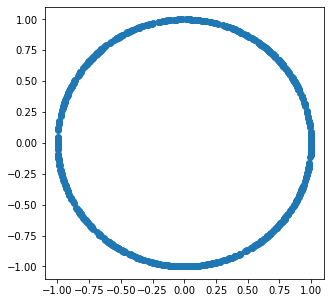

In [68]:
mask = (np.abs(x_2d.numpy())[:,0] > 1e-2) * (np.abs(x_2d.numpy())[:,1] > 1e-2) 

data_higgs = x_2d.numpy()[mask]

plt.figure(figsize=(5,5))
plt.scatter(data_higgs[:,0],data_higgs[:,1])
plt.show()

## Manifold Reconstruction

In [69]:
sampler_circle = SparsePolynomialSampler(
    data_x=data_higgs,
    max_degree=4,
    num_vars=2,
    max_num_monomials=3,
    prob_add= lambda i,n_iter: 0., 
    prob_remove= lambda i,n_iter: 0., 
    prob_modify= lambda i,n_iter: 0.5, 
    prob_multiply= lambda i,n_iter: 0.25, 
    prob_divide= lambda i,n_iter: 0.25, 
    regularisation_factor=1e3,
    sigma_proposal = lambda i,n_iter: 0.1,
    )

Pre-compute multiply/divide transitions...
  Average of multiply transitions: 1.33
  Average of divide transitions: 1.33
Number of possible terms in the polynomial: 15


In [ ]:
# ASMC optimization
all_out = sampler_circle.run_annealing_is(
    n_iter=200,       
    n_particles=1000,  
    verbose=True,
    adaptative_temp=True,
    degree_bias=0.,
    sparsity_factor=0.,
    adaptation_strength=lambda i,n_iter : 0.05,
    target_acc_rate = lambda x,y : 0.8 - 0.5 * x/y,
    beta_schedule=lambda i,n_iter: 1e-10
)


Iteration 1/200, 	Beta: 2.5e-05, 	Acceptance rate: 0.95, 	ESS: 997.33/1000, 	Best loss: 176.032737,	Elapsed time: 0.19s, 	Prob (0.5, 0.25, 0.25, 0.0, 0.0), 	Best pol : -1.3549 + 1.5342*x2^2 + 1.4414*x1^4
Iteration 2/200, 	Beta: 3.8e-05, 	Acceptance rate: 0.96, 	ESS: 985.22/1000, 	Best loss: 176.032737,	Elapsed time: 0.21s, 	Prob (0.5, 0.25, 0.25, 0.0, 0.0), 	Best pol : -1.3549 + 1.5342*x2^2 + 1.4414*x1^4
Iteration 3/200, 	Beta: 5.6e-05, 	Acceptance rate: 0.95, 	ESS: 973.60/1000, 	Best loss: 176.032737,	Elapsed time: 0.24s, 	Prob (0.5, 0.25, 0.25, 0.0, 0.0), 	Best pol : -1.3549 + 1.5316*x2^2 + 1.4414*x1^4
Iteration 4/200, 	Beta: 8.4e-05, 	Acceptance rate: 0.96, 	ESS: 958.15/1000, 	Best loss: 168.676185,	Elapsed time: 0.27s, 	Prob (0.5, 0.25, 0.25, 0.0, 0.0), 	Best pol : -1.3549 + 1.6137*x2^2 + 1.4414*x1^4
Iteration 5/200, 	Beta: 0.00013, 	Acceptance rate: 0.95, 	ESS: 942.95/1000, 	Best loss: 168.676185,	Elapsed time: 0.29s, 	Prob (0.5, 0.25, 0.25, 0.0, 0.0), 	Best pol : -1.3549 + 1.6137

In [71]:
best_coeffs = all_out[0]
bc_trunc = sampler_circle.apply_coefficient_threshold(best_coeffs)
res, loss = sampler_circle.local_search(best_coeffs,n_steps=1000,use_reg=False)

In [72]:
sampler_circle.polynomial_to_string(res)
sampler_circle.min_coeff_threshold = 1e-3
res_trunc = sampler_circle.apply_coefficient_threshold(res)
nonzero_indices = np.nonzero(res_trunc)
coeff_min = np.min(abs(res_trunc[nonzero_indices]))

print(sympy.simplify(sampler_circle.polynomial_to_string(res_trunc/coeff_min))) # Up to a factorisation this should work

x1*x2*(x1**2 + 1.0*x2**2 - 1.0)


# Second Example

In this file we exemplify the workflow to use the `polynomial_sampler.py` module on a toy-model potential.

1. First we obtain a set of 10_000 numerical minima to the potential $V(x) = (x^3 + y^2 + x y z + z -1)^2$
2. Using SparsePolynomialSampler, the locus $x^3 + y^2 + x y z + z = 1$ is reconstructed

In [35]:
# Definition of Potential
def V_3d(x):
    x1, x2, x3 = tf.split(x, 3, axis=1)
    return (x1**3 + x2**2 + x3 + x1*x2*x3 -1)**2

# Randomly initialize the points
n_points = 10000
x_3d = tf.Variable(4*np.random.rand(n_points, 3)-2, dtype=tf.float32)

history_3d = []
history_loss_3d = []

# Definition of optimizer
alpha = 1e-3
optimizer = tf.keras.optimizers.Adam(learning_rate=alpha)

# Learning loop 
for step in range(5000):  
    with tf.GradientTape() as tape:       
        grad_norm_squared_this_step = grad_norm_squared(V_3d, x_3d)
        # minimize ||∇V||^2 for all points
        loss = tf.reduce_sum(grad_norm_squared_this_step)
    
    
    # Compute ||∇V||^2 with respect to x
    gradients = tape.gradient(loss, [x_3d])

    # Update of the optimizer at certain steps
    if step in [250,500,750,1000,1250,1500,1750,2000]:
       optimizer = tf.optimizers.Adam(learning_rate=alpha)
    
    # Apply gradient descent to all points
    optimizer.apply_gradients(zip(gradients, [x_3d]))
    
    history_3d.append(loss)
    history_loss_3d.append(optimizer.learning_rate.numpy())
    
    if step % 10 == 0:

        current_lr = optimizer.learning_rate.numpy()
        print(f"""Step {step}: ||∇V||^2 = {loss.numpy()} with learning rate {current_lr}""")
        
    if np.log(loss.numpy())/np.log(10)<-10: 
        print("Converged enough") 
        print(f"Step {step}: ||∇V||^2 = {loss.numpy()}")
        break

Step 0: ||∇V||^2 = 57537712.0 with learning rate 0.0010000000474974513
Step 10: ||∇V||^2 = 54045000.0 with learning rate 0.0010000000474974513
Step 20: ||∇V||^2 = 50777796.0 with learning rate 0.0010000000474974513
Step 30: ||∇V||^2 = 47743420.0 with learning rate 0.0010000000474974513
Step 40: ||∇V||^2 = 44937104.0 with learning rate 0.0010000000474974513
Step 50: ||∇V||^2 = 42345992.0 with learning rate 0.0010000000474974513
Step 60: ||∇V||^2 = 39953524.0 with learning rate 0.0010000000474974513
Step 70: ||∇V||^2 = 37742352.0 with learning rate 0.0010000000474974513
Step 80: ||∇V||^2 = 35695920.0 with learning rate 0.0010000000474974513
Step 90: ||∇V||^2 = 33799080.0 with learning rate 0.0010000000474974513
Step 100: ||∇V||^2 = 32038192.0 with learning rate 0.0010000000474974513
Step 110: ||∇V||^2 = 30401030.0 with learning rate 0.0010000000474974513
Step 120: ||∇V||^2 = 28876702.0 with learning rate 0.0010000000474974513
Step 130: ||∇V||^2 = 27455456.0 with learning rate 0.001000000

In [36]:
x1 = x_3d.numpy()[:,0]
x2 = x_3d.numpy()[:,1]
x3 = x_3d.numpy()[:,2]

In [37]:
np.sum((x1**3 + x2**2 + x3 + x1*x2*x3 - 1)**2)

501.48804

In [47]:
print(np.sum(((x1**3 + x2**2 + x3 + x1*x2*x3 - 1)**2)<1e-1))
#some points have converged on another locus : remove them 
mask = ((x1**3 + x2**2 + x3 + x1*x2*x3 - 1)**2)<1e-4
x_3d_filtered = x_3d.numpy()[mask,:]
print(x_3d_filtered.shape)

9456
(9456, 3)


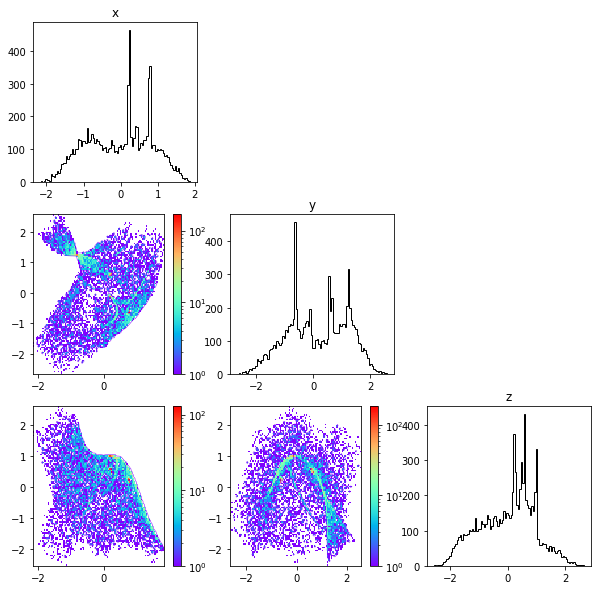

In [48]:
utils.triangular_plot(x_3d_filtered,names=['x','y','z'],figsize=(10,10))

In [58]:
sampler_3d = SparsePolynomialSampler(
    data_x=x_3d_filtered,
    max_degree=5,
    num_vars=3,
    max_num_monomials=6,
    prob_add= lambda i,n_iter: 0., 
    prob_remove= lambda i,n_iter: 0., 
    prob_modify= lambda i,n_iter: 0.1, 
    prob_multiply= lambda i,n_iter: 0.45, 
    prob_divide= lambda i,n_iter: 0.45, 
    regularisation_factor=1e3,
    sigma_proposal = lambda i,n_iter: 0.1,
    )

Pre-compute multiply/divide transitions...
  Average of multiply transitions: 1.88
  Average of divide transitions: 1.88
Number of possible terms in the polynomial: 56


In [59]:
# ASMC optimization
all_out = sampler_3d.run_annealing_is(
    n_iter=1000,       
    n_particles=1000,  
    verbose=True,
    adaptative_temp=True,
    degree_bias=0.,
    sparsity_factor=0.,
    adaptation_strength=lambda i,n_iter : 0.05,
    target_acc_rate = lambda x,y : 0.8 - 0.5 * x/y,
    beta_schedule=lambda i,n_iter: 1e-8
)


Iteration 1/1000, 	Beta: 1e-08, 	Acceptance rate: 1.00, 	ESS: 1000.00/1000, 	Best loss: 17776.727444,	Elapsed time: 0.42s, 	Prob (0.1, 0.45, 0.45, 0.0, 0.0), 	Best pol : 0.3799*x2*x3 - 0.0090*x2*x3^2 - 0.3344*x2^2*x3 - 0.3580*x1*x2^2 + 0.4384*x2*x3^3 - 0.5809*x1^2*x2*x3
Iteration 2/1000, 	Beta: 1.1e-08, 	Acceptance rate: 1.00, 	ESS: 999.99/1000, 	Best loss: 17776.727444,	Elapsed time: 0.75s, 	Prob (0.1, 0.45, 0.45, 0.0, 0.0), 	Best pol : 0.3799*x2*x3 - 0.1762*x2*x3^2 - 0.3344*x2^2*x3 - 0.3580*x1*x2^2 + 0.4384*x2*x3^3 - 0.5809*x1^2*x2*x3
Iteration 3/1000, 	Beta: 1.1e-08, 	Acceptance rate: 1.00, 	ESS: 999.98/1000, 	Best loss: 17776.727444,	Elapsed time: 1.10s, 	Prob (0.1, 0.45, 0.45, 0.0, 0.0), 	Best pol : 0.9264*x1*x2^2*x3 + 0.6244*x1^2*x2^2 + 0.2290*x1*x2^2*x3^2 + 0.2629*x1*x2^4 - 0.0065*x1^3*x2*x3
Iteration 4/1000, 	Beta: 1.2e-08, 	Acceptance rate: 1.00, 	ESS: 999.97/1000, 	Best loss: 17581.929570,	Elapsed time: 1.49s, 	Prob (0.1, 0.45, 0.45, 0.0, 0.0), 	Best pol : 0.1838*x1 - 0.1616*

In [63]:
best_coeffs = all_out[0]
bc_trunc = sampler_3d.apply_coefficient_threshold(best_coeffs)
res, loss = sampler_3d.local_search(best_coeffs,n_steps=10000,use_reg=False)

In [64]:
sampler_3d.polynomial_to_string(res)
sampler_3d.min_coeff_threshold = 1e-3
res_trunc = sampler_3d.apply_coefficient_threshold(res)
nonzero_indices = np.nonzero(res_trunc)
coeff_min = np.min(abs(res_trunc[nonzero_indices]))

print(sympy.simplify(sampler_3d.polynomial_to_string(res_trunc/coeff_min))) # Up to a factorisation this should work

1.0*x1**3 + 1.0*x1*x2*x3 + 1.0001*x2**2 + x3 - 1.0
